# Manually Run the action recognition pipeline

This notebook is used to manually run and visualise each step of the action recognition pipeline. This is helpful for testing, debugging, and using as a live demo. Many of the below steps are automated and optimised in the 'scripts' and 'src' python files. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.append(str(project_root))

In [3]:
import torch

from src.aggregation import MeanPooling, QueryScoringAggregator
from src.prompting import MPVRPrompts, TemplatePrompts
from src.sampling import MotionGuidedSampler, UniformSampler
from src.utils import clip
from src.utils.clip import get_video_embeddings
from src.utils.dataset import VideoDataset
from src.video_classifier import VideoClassifier
from pathlib import Path
import pandas as pd
import numpy as np
from src.utils.constants import (
    RESULTS_DIR,
    PROJECT_ROOT,
    ACTIVITYNET_CSV,
    ACTIVITYNET_EMBEDDINGS_DIR,
)

import torch.nn.functional as functional

c:\Users\kokos\anaconda3\envs\zsar_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Choose video for input to pipeline

In [ ]:
from src.utils.constants import ACTIVITYNET_VIDEOS_DIR


metadata_cols = [
    "clip_name",
    "clip_path",
    "label",
    "frame_count",
    "duration_sec",
    "fps",
    "width",
    "height",
    "resolution",
    "video_id",
    "fo_id",
]

# Samplers:
# df1 = pd.read_csv(RESULTS_DIR / "activitynet_all_combinations_16" / "UniformSampler16_MeanPooling_MPVRPrompts.csv")
# df2 = pd.read_csv(RESULTS_DIR / "activitynet_all_combinations_16" / "MGSampler16_MeanPooling_MPVRPrompts.csv")

# Aggregators:
# df1 = pd.read_csv(RESULTS_DIR / "activitynet_all_combinations_16" / "UniformSampler16_QueryScoringAggregator_MPVRPrompts.csv")
# df2 = pd.read_csv(RESULTS_DIR / "activitynet_all_combinations_16" / "UniformSampler16_MeanPooling_MPVRPrompts.csv")

# Prompting:
df1 = pd.read_csv(RESULTS_DIR / "activitynet_t100_16" / "UniformSampler16_MeanPooling_MPVRPrompts.csv")
df2 = pd.read_csv(RESULTS_DIR / "activitynet_t100_16" / "UniformSampler16_MeanPooling_TemplatePrompts.csv")

class_cols = df1.columns.drop(metadata_cols, errors="ignore").tolist()

y_true = df1["label"].to_numpy()

y_pred1 = df1[class_cols].idxmax(axis=1).to_numpy()
y_pred2 = df2[class_cols].idxmax(axis=1).to_numpy()

acc_1 = y_pred1 == y_true
acc_2 = y_pred2 == y_true

# Find indices where the condition is true (configuration 1 is correct but configuration 2 is wrong)
target_indices = np.where(acc_1 & ~acc_2)[0]

video_path: Path = None

if len(target_indices) > 0:
    random_idx = np.random.choice(target_indices)
    # random_idx = 825
    # Good indexes:
    # Samplers: (used 637, 39)
    # Aggregators: 69, ( used 421), 193
    # Prompting: 825, 207, 312, 785, 768, (used 364)

    video_path = ACTIVITYNET_VIDEOS_DIR / df1['clip_path'][random_idx]
    print(f"Chosen Video: {video_path}")

    print(f"Index: {random_idx}")
    print(f"True Label: {y_true[random_idx]}\n")
    print(f"Model 1 Predicted: {y_pred1[random_idx]}")
    print(f"Model 2 Predicted: {y_pred2[random_idx]}")

    # Now print the probabilities for the top predicted classes per model
    probs1 = df1.loc[random_idx, class_cols]
    probs2 = df2.loc[random_idx, class_cols]

    top_n_1 = probs1.sort_values(ascending=False).head(5)
    top_n_2 = probs2.sort_values(ascending=False).head(5)

    print("\nModel 1:")
    for cls, score in top_n_1.items():
        print(f"  {cls}: {score:.4f}")

    print("\nModel 2:")
    for cls, score in top_n_2.items():
        print(f"  {cls}: {score:.4f}")
else:
    print("No instances found where Model 1 was correct and Model 2 was wrong.")


Chosen Video: C:\Users\kokos\Home\vlm-zsar-dissertation\data\activitynet\videos\Washing_hands\v_x44fn0snUvw.mp4
Index: 364
True Label: Washing hands

Model 1 Predicted: Washing hands
Model 2 Predicted: Cleaning sink

Model 1:
  Washing hands: 0.5831
  Cleaning sink: 0.0768
  Doing nails: 0.0760
  Washing face: 0.0719
  Shaving legs: 0.0510

Model 2:
  Cleaning sink: 0.3126
  Washing hands: 0.2943
  Doing nails: 0.1076
  Shaving legs: 0.0724
  Washing face: 0.0697


## Analyse Samplers

In [142]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.sampling import Sampler
from src.utils.clip import extract_selected_frames


def get_video_frame_count(video_path):
    cap = cv2.VideoCapture(str(video_path))
    try:
        return int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    finally:
        cap.release()


def visualise_sampler(video_path, sampler: Sampler, num_frames_to_display=3):
    """Visualises the frame sampling timeline and selected example frames."""
    selected = np.array(sampler.sample(video_path))
    total_frames = get_video_frame_count(video_path)
    frames = extract_selected_frames(video_path, selected)

    example_ids = np.linspace(0, len(selected) - 1, num_frames_to_display, dtype=int)

    layout = [
        ["timeline"] * num_frames_to_display,
        [f"img_{i}" for i in range(num_frames_to_display)],
    ]

    fig, axes = plt.subplot_mosaic(
        layout,
        figsize=(4 * num_frames_to_display, 5),
        height_ratios=[1, 3.25],
    )

    # timeline setup
    ax_time: plt.Axes = axes["timeline"]
    ax_time.set_title(f"{sampler.name} Frame Sampling", pad=12, fontsize=14)
    ax_time.hlines(0, 0, total_frames)
    ax_time.scatter(selected, np.zeros_like(selected), color="grey")
    ax_time.scatter(
        selected[example_ids], np.ones_like(example_ids) * 0.05, color="red"
    )

    # put index of selected frames on timeline
    for i, idx in enumerate(selected):
        ax_time.text(idx, -0.04, str(i), ha="center")

    ax_time.set(xlim=(0, total_frames), ylim=(-0.08, 0.1), yticks=[])
    ax_time.set_xlabel("Video Frame Index", fontsize=14)

    # 'example frames' setup
    for i, sample_id in enumerate(example_ids):
        ax_img: plt.Axes = axes[f"img_{i}"]
        ax_img.imshow(frames[sample_id])
        ax_img.set(xticks=[], yticks=[])
        ax_img.set_xlabel(
            f"Sample {sample_id} | Frame {selected[sample_id]}", fontsize=14
        )

    plt.show()
    return selected

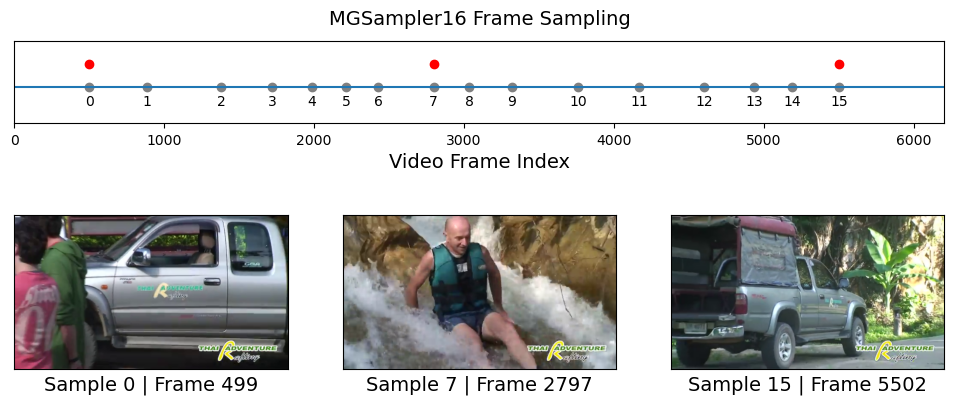

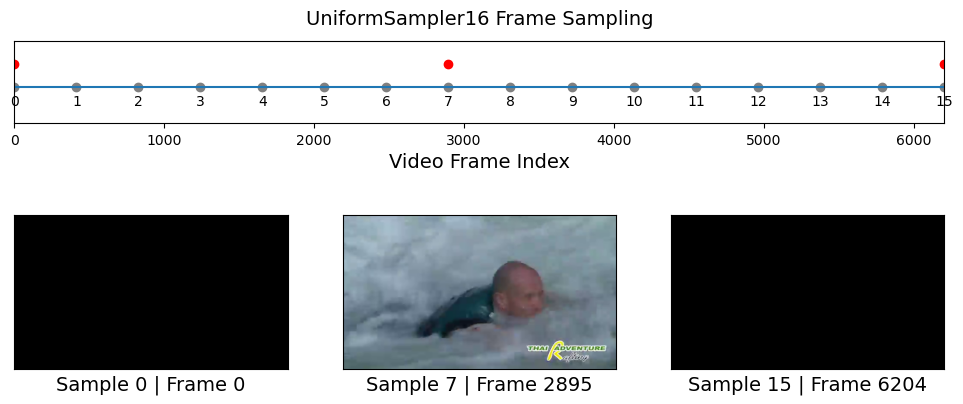

array([   0,  414,  827, 1241, 1654, 2068, 2482, 2895, 3309, 3722, 4136,
       4550, 4963, 5377, 5790, 6204])

In [170]:
mgsampler = MotionGuidedSampler(16)
uniform_sampler = UniformSampler(16)

visualise_sampler(
    video_path,
    mgsampler,
    num_frames_to_display=3,
)

visualise_sampler(
    video_path,
    uniform_sampler,
    num_frames_to_display=3,
)

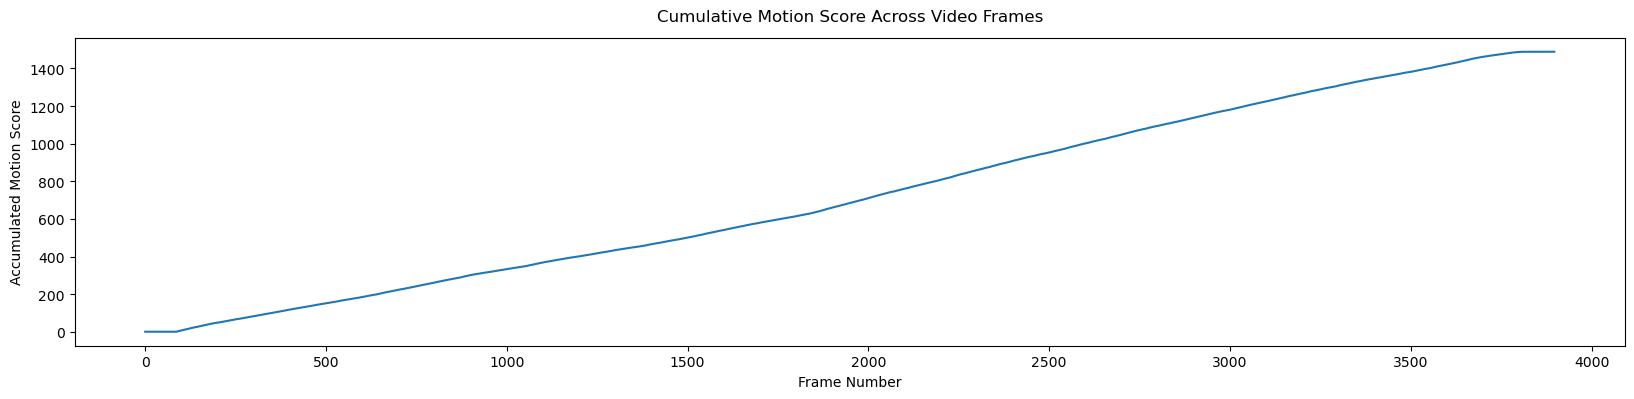

In [7]:
cumsum_diff = np.cumsum(mgsampler._cache[str(video_path)])

plt.figure(figsize=(20, 4))
plt.title("Cumulative Motion Score Across Video Frames", pad=12)
plt.xlabel("Frame Number")
plt.ylabel("Accumulated Motion Score")
plt.plot(cumsum_diff)

## Analyse aggregators

In [106]:
from src.utils.constants import MPVR_ACTIVITYNET_CLASS_DESC_JSON


classes = VideoDataset(
    ACTIVITYNET_EMBEDDINGS_DIR,
    ACTIVITYNET_VIDEOS_DIR,
    ACTIVITYNET_CSV,
).get_classes()

classifier = VideoClassifier(classes)
classifier.set_sampler(UniformSampler(6))
classifier.set_aggregator(QueryScoringAggregator())
classifier.set_prompter(MPVRPrompts(classes, MPVR_ACTIVITYNET_CLASS_DESC_JSON))
classifier.classify(video_path)

Generating MPVR embeddings: 100%|██████████| 199/199 [00:57<00:00,  3.47it/s]


Extracting frame embeddings for video: C:\Users\kokos\Home\vlm-zsar-dissertation\data\activitynet\videos\Making_a_sandwich\v_1ebIpLiTCvw.mp4


tensor([8.4502e-04, 2.0251e-03, 5.3075e-03, 1.5454e-02, 1.9238e-03, 1.9719e-03,
        3.3919e-04, 5.7654e-04, 7.9568e-04, 4.0431e-05, 1.9260e-03, 5.6560e-04,
        3.4691e-03, 1.2018e-03, 2.2120e-03, 6.1895e-04, 3.5785e-03, 8.7410e-04,
        2.8239e-04, 4.9362e-04, 1.6913e-03, 1.9093e-04, 6.3248e-04, 6.6457e-04,
        2.6679e-04, 8.0696e-04, 1.2867e-02, 3.6365e-04, 1.2746e-03, 3.3080e-04,
        2.5633e-03, 2.1084e-03, 4.9659e-03, 7.0404e-03, 9.5672e-04, 7.0411e-05,
        3.8045e-04, 1.2690e-03, 1.9932e-03, 1.7970e-04, 2.0747e-04, 6.6792e-04,
        2.3956e-04, 1.7478e-03, 1.4062e-03, 4.7163e-04, 1.0250e-03, 1.2919e-03,
        6.4080e-04, 2.3448e-03, 2.9346e-04, 2.1326e-03, 1.1966e-03, 5.1324e-04,
        3.1920e-03, 1.0239e-02, 1.4592e-03, 2.9892e-03, 7.9679e-05, 1.4025e-03,
        1.4571e-03, 8.0188e-04, 5.4423e-04, 9.1115e-04, 6.2982e-04, 8.1225e-03,
        1.9577e-03, 1.7710e-03, 1.8565e-03, 5.3656e-04, 1.2916e-03, 1.8145e-04,
        5.1603e-04, 1.5586e-03, 2.3310e-

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def visualise_extreme_scores(frames, scores, frame_indices):
    """Displays the highest and lowest scoring frames next to each other"""
    best_idx, worst_idx = np.argmax(scores), np.argmin(scores)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, idx, title in zip(axes, [best_idx, worst_idx], ["Highest", "Lowest"]):
        ax.imshow(frames[idx])
        ax.set(
            title=f"{title} Score: {scores[idx]:.3f}",
            xlabel=f"Frame {frame_indices[idx]}",
            xticks=[],
            yticks=[],
        )

    plt.tight_layout()
    plt.show()


def visualise_frame_weights(frames, scores, frame_indices, num_frames=5):
    """shows the subset of selected frames, with a bar chart showing the score of each frame directly above the frame"""
    total_frames = len(frames)
    num_frames = min(num_frames, total_frames)

    # Pick evenly spaced frames to display from selected frames
    display_ids = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    layout = [["bar"] * num_frames, [f"img_{i}" for i in range(num_frames)]]
    fig, axes = plt.subplot_mosaic(
        layout, figsize=(2 * num_frames, 3), height_ratios=[1, 2]
    )

    # Plot the bar chart
    ax_bar = axes["bar"]
    selected_scores = [scores[i] for i in display_ids]
    ax_bar.bar(range(num_frames), selected_scores, color="steelblue")
    ax_bar.set(
        xlim=(-0.5, num_frames - 0.5),
        xticks=[],
    )
    ax_bar.set_title("Aggregator Frame Scores", fontsize=14)
    ax_bar.set_ylabel("Score", fontsize=12)

    # Plot the images
    for i, idx in enumerate(display_ids):
        ax_img = axes[f"img_{i}"]
        ax_img.imshow(frames[idx])
        ax_img.set(
            xticks=[],
            yticks=[],
        )
        ax_img.set_xlabel(
            f"Frame {frame_indices[idx]}\nScore: {scores[idx]:.2f}", fontsize=14
        )

    plt.show()

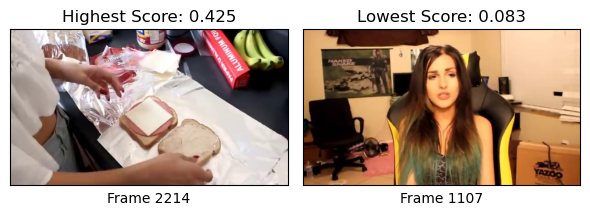

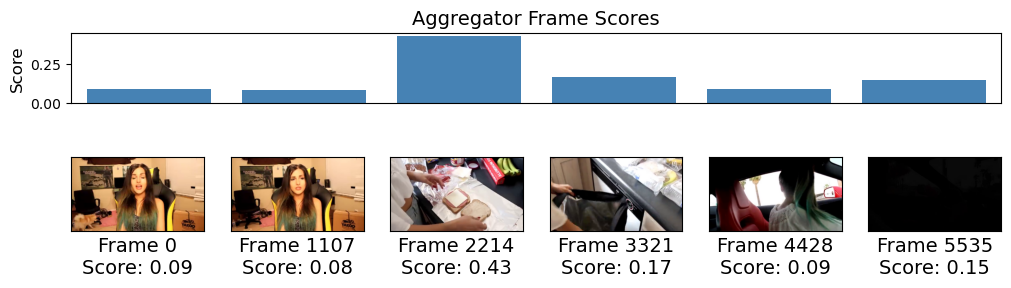

In [120]:
frame_weights = classifier.aggregator.saved_frame_weights
selected_indices = classifier.sampler.sample(video_path)
frames = extract_selected_frames(video_path, selected_indices)

visualise_extreme_scores(frames, frame_weights, selected_indices)

visualise_frame_weights(frames, frame_weights, selected_indices, num_frames=8)
